In [1]:
!pip install torch torchvision ultralytics opencv-python-headless matplotlib scikit-learn seaborn -q

import torch, torch.nn as nn, torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.7 MB/s eta 0:00:00
Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_set = datasets.GTSRB(root="./data", split="train", download=True, transform=transform)
test_set  = datasets.GTSRB(root="./data", split="test",  download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

num_classes = 43
print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")

100%|██████████| 187M/187M [00:15<00:00, 11.8MB/s]
100%|██████████| 89.0M/89.0M [00:08<00:00, 10.2MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 184kB/s]


Train samples: 26640, Test samples: 12630


In [3]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [4]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

def build_mobilenet(num_classes=43, freeze_backbone=True):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1
    model = mobilenet_v2(weights=weights)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model

In [5]:
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet18(num_classes=43, freeze_backbone=True):
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if not name.startswith("fc"):
                param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [6]:
def train_model(model, train_loader, test_loader, epochs=8, lr=1e-3, name="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {"train_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

    training_time = time.time() - start_time
    n_params = sum(p.numel() for p in model.parameters())
    return {
        "model": model,
        "history": history,
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "training_time_sec": training_time,
        "num_params": n_params
    }

In [ ]:
EPOCHS = 10
LR = 1e-3


print("Training Model 1: Custom CNN (scratch)")

model1 = TrafficSignCNN(num_classes)
result1 = train_model(model1, train_loader, test_loader, epochs=EPOCHS, lr=LR, name="CustomCNN")


print("Training Model 2: MobileNetV2 (transfer learning)")

model2 = build_mobilenet(num_classes, freeze_backbone=True)
result2 = train_model(model2, train_loader, test_loader, epochs=EPOCHS, lr=LR, name="MobileNetV2")


print("Training Model 3: ResNet18 (transfer learning)")

model3 = build_resnet18(num_classes, freeze_backbone=True)
result3 = train_model(model3, train_loader, test_loader, epochs=EPOCHS, lr=LR, name="ResNet18")

results = {
    "Custom CNN": result1,
    "MobileNetV2": result2,
    "ResNet18": result3
}

Training Model 1: Custom CNN (scratch)
[CustomCNN] Epoch 1/10 | Loss: 1.8246 | Val Accuracy: 78.33%
[CustomCNN] Epoch 2/10 | Loss: 0.4661 | Val Accuracy: 90.37%
[CustomCNN] Epoch 3/10 | Loss: 0.2327 | Val Accuracy: 94.00%
[CustomCNN] Epoch 4/10 | Loss: 0.1539 | Val Accuracy: 94.54%
[CustomCNN] Epoch 5/10 | Loss: 0.1219 | Val Accuracy: 95.16%
[CustomCNN] Epoch 6/10 | Loss: 0.1043 | Val Accuracy: 95.31%
[CustomCNN] Epoch 7/10 | Loss: 0.0904 | Val Accuracy: 95.38%
[CustomCNN] Epoch 8/10 | Loss: 0.0726 | Val Accuracy: 95.18%
[CustomCNN] Epoch 9/10 | Loss: 0.0685 | Val Accuracy: 96.28%
[CustomCNN] Epoch 10/10 | Loss: 0.0685 | Val Accuracy: 95.87%
Training Model 2: MobileNetV2 (transfer learning)
[MobileNetV2] Epoch 1/10 | Loss: 1.5481 | Val Accuracy: 48.39%
[MobileNetV2] Epoch 2/10 | Loss: 0.9819 | Val Accuracy: 49.90%
[MobileNetV2] Epoch 3/10 | Loss: 0.8567 | Val Accuracy: 51.54%
[MobileNetV2] Epoch 4/10 | Loss: 0.8053 | Val Accuracy: 51.73%
[MobileNetV2] Epoch 5/10 | Loss: 0.7659 | Val Ac

             Best Val Acc (%)  Final Val Acc (%)  Training Time (s)  \
Custom CNN          96.159937          94.940618              265.9   
MobileNetV2         51.813143          51.480602              255.4   
ResNet18            50.958036          50.253365              248.3   

             Parameters (M)  
Custom CNN             2.20  
MobileNetV2            2.28  
ResNet18              11.20  


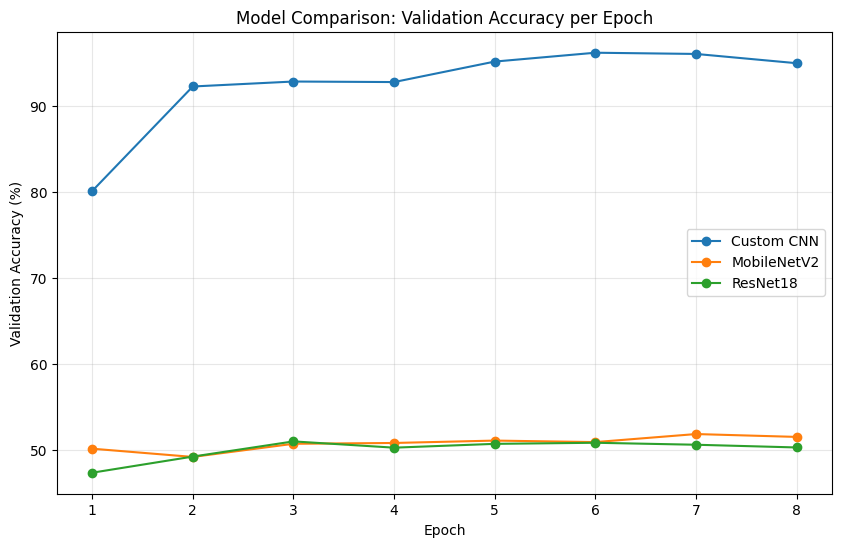

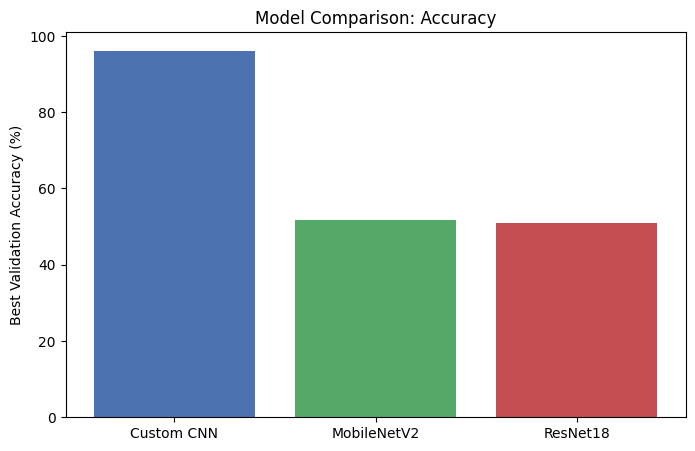

In [8]:
import pandas as pd

comparison = pd.DataFrame({
    name: {
        "Best Val Acc (%)": r["best_val_acc"],
        "Final Val Acc (%)": r["final_val_acc"],
        "Training Time (s)": round(r["training_time_sec"], 1),
        "Parameters (M)": round(r["num_params"] / 1e6, 2)
    } for name, r in results.items()
}).T

print(comparison)

plt.figure(figsize=(10, 6))
for name, r in results.items():
    plt.plot(range(1, EPOCHS+1), r["history"]["val_acc"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Model Comparison: Validation Accuracy per Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs = [results[n]["best_val_acc"] for n in names]
params = [results[n]["num_params"]/1e6 for n in names]

ax1.bar(names, accs, color=['#4C72B0','#55A868','#C44E52'])
ax1.set_ylabel("Best Validation Accuracy (%)")
ax1.set_title("Model Comparison: Accuracy")
plt.show()

In [9]:
best_name = max(results, key=lambda n: results[n]["best_val_acc"])
best_model = results[best_name]["model"]
print(f"Best model selected: {best_name} with {results[best_name]['best_val_acc']:.2f}% validation accuracy")
print(f"Parameters: {results[best_name]['num_params']/1e6:.2f}M | Training time: {results[best_name]['training_time_sec']:.1f}s")

Best model selected: Custom CNN with 96.16% validation accuracy
Parameters: 2.20M | Training time: 265.9s


In [10]:
if best_name == "MobileNetV2":
    for param in best_model.features[-4:].parameters():
        param.requires_grad = True
elif best_name == "ResNet18":
    for param in best_model.layer4.parameters():
        param.requires_grad = True

if best_name != "Custom CNN":
    finetune_result = train_model(best_model, train_loader, test_loader, epochs=5, lr=1e-4, name=f"{best_name}-finetuned")
    best_model = finetune_result["model"]
    print(f"After fine-tuning: {finetune_result['best_val_acc']:.2f}% validation accuracy")

Final Evaluation — Best Model: Custom CNN

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.94      0.98      0.96       720
           2       0.92      1.00      0.96       750
           3       0.94      0.94      0.94       450
           4       0.98      0.97      0.97       660
           5       0.79      0.97      0.87       630
           6       1.00      0.63      0.77       150
           7       0.96      0.86      0.91       450
           8       0.95      0.89      0.92       450
           9       0.95      1.00      0.98       480
          10       1.00      0.98      0.99       660
          11       0.96      0.94      0.95       420
          12       1.00      0.96      0.98       690
          13       0.91      1.00      0.95       720
          14       0.96      1.00      0.98       270
          15       0.98      0.93      0.95       210
          16       1.00      0.95     

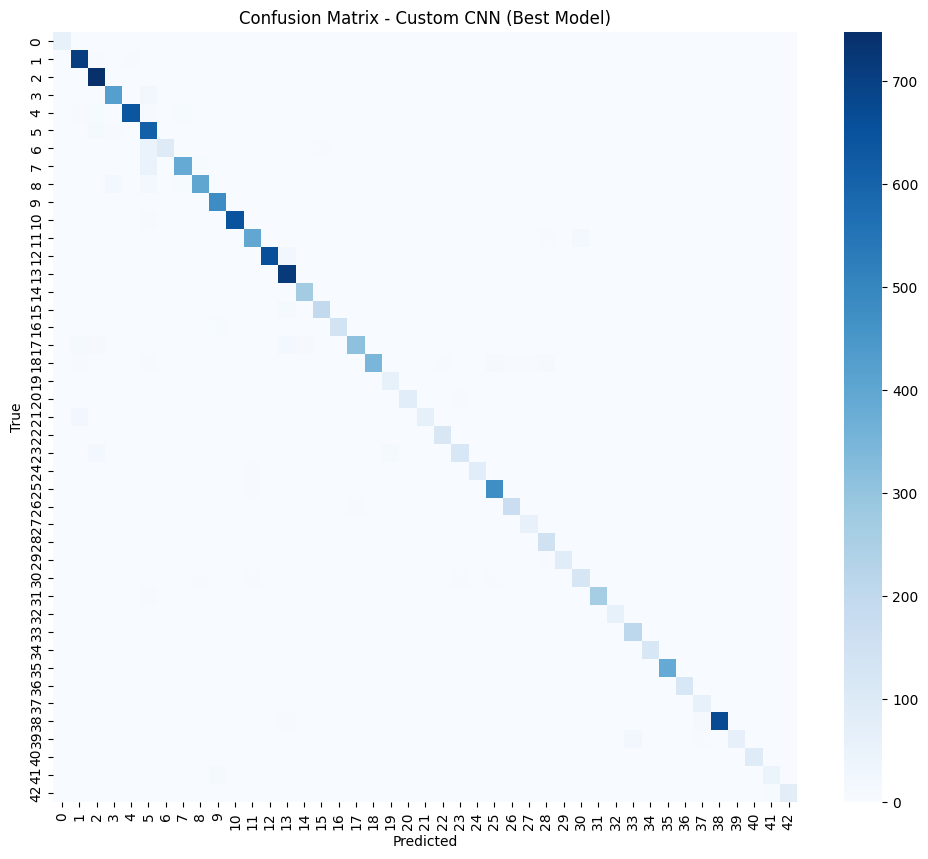

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = best_model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(f"Final Evaluation — Best Model: {best_name}\n")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {best_name} (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

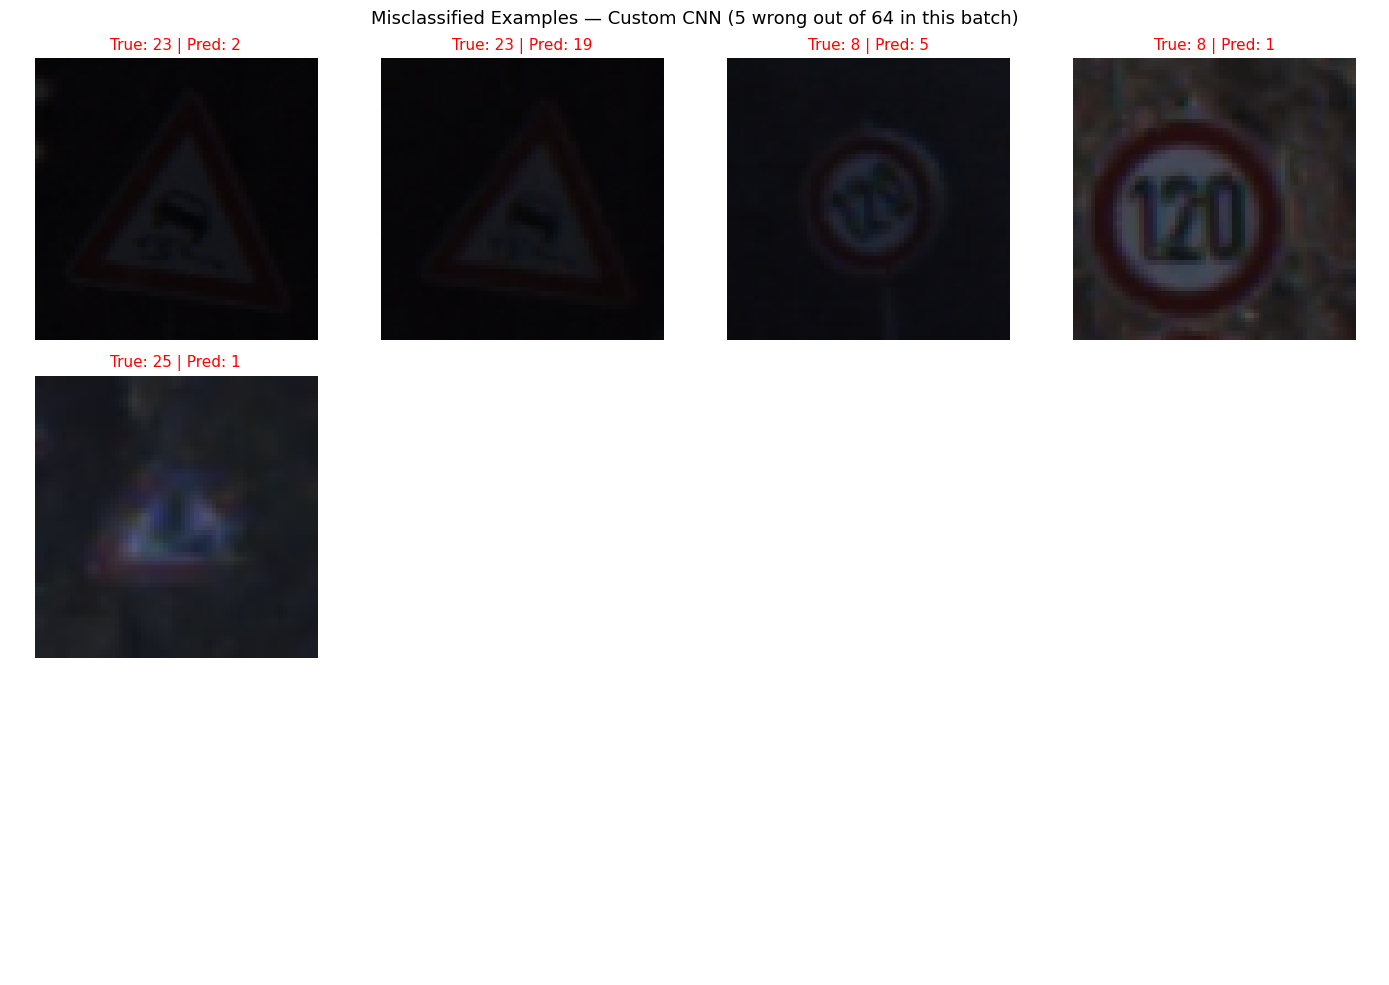

In [14]:
# Show only misclassified examples — these tell you where the model struggles
wrong_idxs = [i for i in range(len(imgs)) if preds[i].item() != labels[i].item()]

if len(wrong_idxs) == 0:
    print("All predictions in this batch were correct!")
else:
    n_show = min(12, len(wrong_idxs))
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()

    for ax, idx in zip(axes, wrong_idxs[:n_show]):
        img = unnormalize(imgs[idx])
        ax.imshow(img)
        ax.set_title(f"True: {labels[idx].item()} | Pred: {preds[idx].item()}", color="red", fontsize=11)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    plt.suptitle(f"Misclassified Examples — {best_name} ({len(wrong_idxs)} wrong out of {len(imgs)} in this batch)", fontsize=13)
    plt.tight_layout()
    plt.show()

In [16]:
transform = transforms.Compose([
    transforms.Resize((64, 64), interpolation=transforms.InterpolationMode.BILINEAR, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    return img

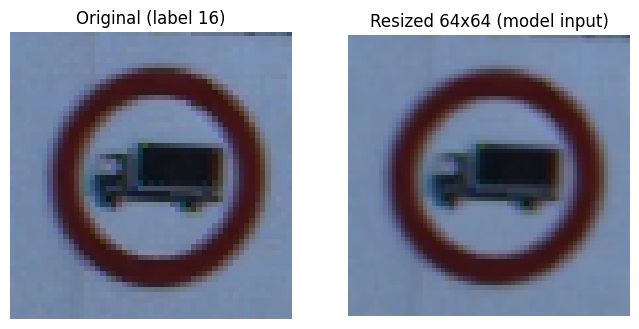

In [17]:

raw_transform = transforms.Compose([transforms.ToTensor()])
raw_test_set = datasets.GTSRB(root="./data", split="test", download=True, transform=raw_transform)

idx = 0
raw_img, raw_label = raw_test_set[idx]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_img.permute(1, 2, 0))
axes[0].set_title(f"Original (label {raw_label})")
axes[0].axis("off")

axes[1].imshow(unnormalize(imgs[idx]))
axes[1].set_title("Resized 64x64 (model input)")
axes[1].axis("off")
plt.show()

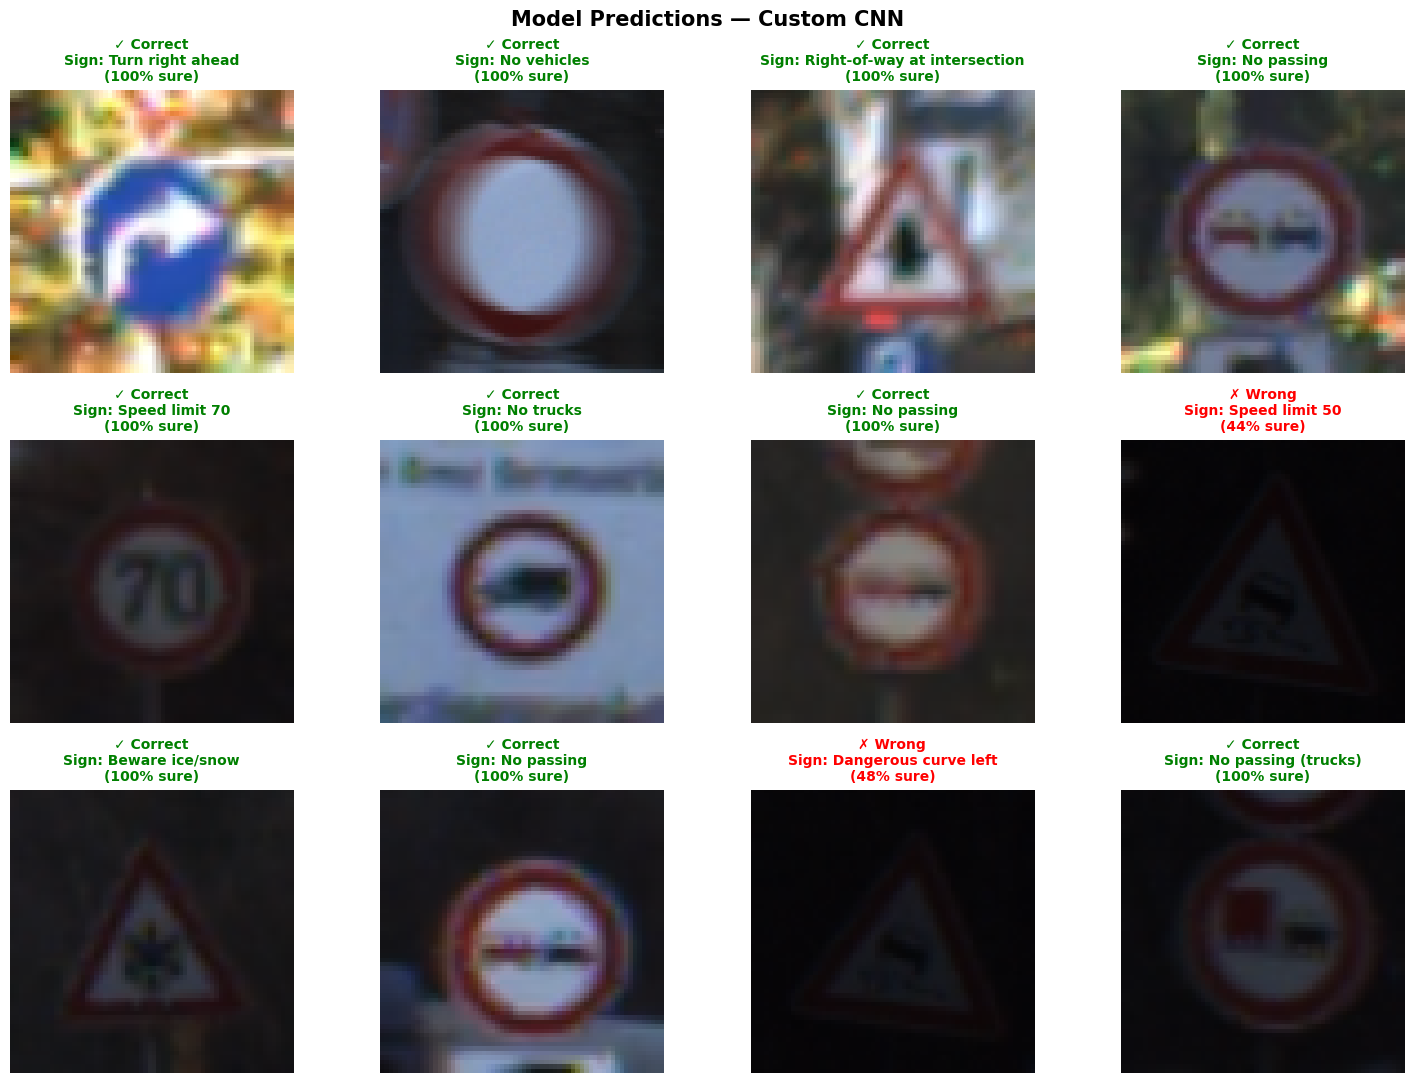

In [18]:
# Clean visualization: Sign name + Correct/Wrong (no class ID numbers shown)

class_names = [
    "Speed limit 20", "Speed limit 30", "Speed limit 50", "Speed limit 60",
    "Speed limit 70", "Speed limit 80", "End speed limit 80", "Speed limit 100",
    "Speed limit 120", "No passing", "No passing (trucks)",
    "Right-of-way at intersection", "Priority road", "Yield", "Stop",
    "No vehicles", "No trucks", "No entry", "General caution",
    "Dangerous curve left", "Dangerous curve right", "Double curve",
    "Bumpy road", "Slippery road", "Road narrows right", "Road work",
    "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Beware ice/snow", "Wild animals crossing", "End of all limits",
    "Turn right ahead", "Turn left ahead", "Ahead only", "Go straight or right",
    "Go straight or left", "Keep right", "Keep left", "Roundabout mandatory",
    "End of no passing", "End of no passing (trucks)"
]

def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5
    return np.clip(img, 0, 1)

data_iter = iter(test_loader)
imgs, labels = next(data_iter)
imgs, labels = imgs.to(device), labels.to(device)

best_model.eval()
with torch.no_grad():
    outputs = best_model(imgs)
    probs = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, dim=1)

n_show = 12
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
axes = axes.flatten()

idxs = random.sample(range(len(imgs)), n_show)
for ax, idx in zip(axes, idxs):
    img = unnormalize(imgs[idx])
    true_name = class_names[labels[idx].item()]
    pred_name = class_names[preds[idx].item()]
    confidence = confs[idx].item() * 100
    correct = labels[idx].item() == preds[idx].item()

    ax.imshow(img)
    status = "✓ Correct" if correct else "✗ Wrong"
    ax.set_title(f"{status}\nSign: {pred_name}\n({confidence:.0f}% sure)",
                 color="green" if correct else "red", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"Model Predictions — {best_name}", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()